In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cardio_train.csv", sep=";")

# Kolumner printas ut för att ge en överblick över vilka features som finns.
print(df.columns)

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')


### EDA

I denna del utförs EDA (Exploratory Data Analysis) för att få en blick över hur datan är fördelad och vilka värden som finns. 


In [32]:
print(df.info())



<class 'pandas.core.frame.DataFrame'>
Index: 68715 entries, 0 to 69999
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   id            68715 non-null  int64   
 1   age           68715 non-null  int64   
 2   gender        68715 non-null  int64   
 3   height        68715 non-null  int64   
 4   weight        68715 non-null  float64 
 5   ap_hi         68715 non-null  int64   
 6   ap_lo         68715 non-null  int64   
 7   cholesterol   68715 non-null  int64   
 8   gluc          68715 non-null  int64   
 9   smoke         68715 non-null  int64   
 10  alco          68715 non-null  int64   
 11  active        68715 non-null  int64   
 12  cardio        68715 non-null  int64   
 13  age_years     68715 non-null  float64 
 14  BMI           68715 non-null  float64 
 15  BMI_category  68077 non-null  category
 16  BP_category   68715 non-null  object  
dtypes: category(1), float64(3), int64(12), object(1)
memory

In [33]:
print(df.describe()) 

                 id           age        gender        height        weight  \
count  68715.000000  68715.000000  68715.000000  68715.000000  68715.000000   
mean   49972.564302  19464.339169      1.348788    164.410202     74.091245   
std    28844.694261   2467.893363      0.476590      7.943092     14.212719   
min        0.000000  10798.000000      1.000000    100.000000     28.000000   
25%    24999.000000  17657.000000      1.000000    159.000000     65.000000   
50%    50017.000000  19701.000000      1.000000    165.000000     72.000000   
75%    74861.500000  21324.000000      2.000000    170.000000     82.000000   
max    99999.000000  23713.000000      2.000000    250.000000    200.000000   

              ap_hi         ap_lo   cholesterol          gluc         smoke  \
count  68715.000000  68715.000000  68715.000000  68715.000000  68715.000000   
mean     126.612108     81.376017      1.364855      1.226079      0.088001   
std       16.757375      9.687415      0.679083    

In [2]:
# Hur många personer har hjärt- och kärlsjukdomar och hur många har det inte?
sick = df["cardio"].value_counts()[1]
healthy = df["cardio"].value_counts()[0]

print(f"Personer med hjärt- och kärlsjukdomar: {sick}")
print(f"Personer utan hjärt- och kärlsjukdomar: {healthy}")

Personer med hjärt- och kärlsjukdomar: 34979
Personer utan hjärt- och kärlsjukdomar: 35021


Personer med kolesterolnivåer runt normalen: 52385
Personer med kolesterolnivåer över det normala: 9549
Personer med kolesterolnivåer långt över det normala: 8066


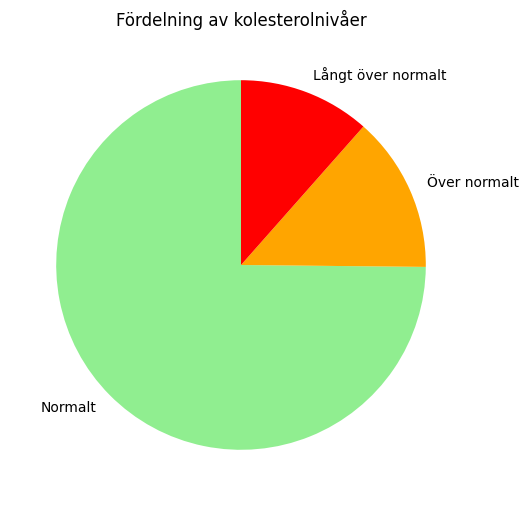

In [3]:
# Hur är kolesterolnivåerna fördelade i datasetet?

normal_chol = df["cholesterol"].value_counts()[1]
raised_chol = df["cholesterol"].value_counts()[2]
high_chol = df["cholesterol"].value_counts()[3]
print(f"Personer med kolesterolnivåer runt normalen: {normal_chol}")
print(f"Personer med kolesterolnivåer över det normala: {raised_chol}")
print(f"Personer med kolesterolnivåer långt över det normala: {high_chol}")

chol_counts = df["cholesterol"].value_counts().sort_index()

labels = ["Normalt", "Över normalt", "Långt över normalt"]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(chol_counts, labels=labels, startangle=90, colors=["lightgreen", "orange", "red"])

ax.set_title("Fördelning av kolesterolnivåer")

plt.show()



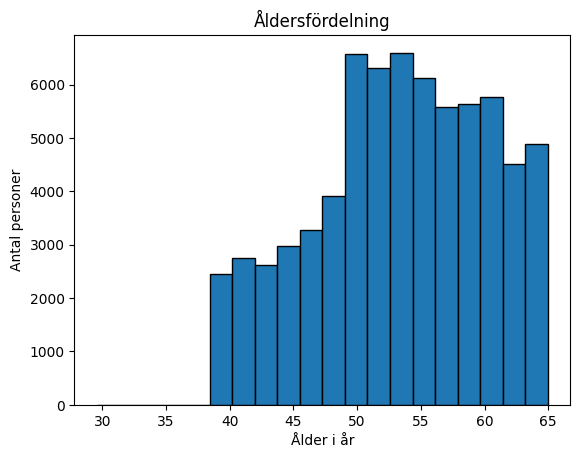

In [4]:
# Hur ser ålderfördelningen ut?

ages = df["age"].values

# Åldern omvandlas från dagar till år för att göra det mer lättläst.
df["age_years"] = df["age"] / 365  

plt.hist(df["age_years"], bins=20, edgecolor='black')
plt.xlabel("Ålder i år")
plt.ylabel("Antal personer")
plt.title("Åldersfördelning")
plt.show()


In [5]:
# Hur många röker?

df_smokers = df[df["smoke"] == 1]
print(f"Antal rökare: {len(df_smokers)}")

Antal rökare: 6169


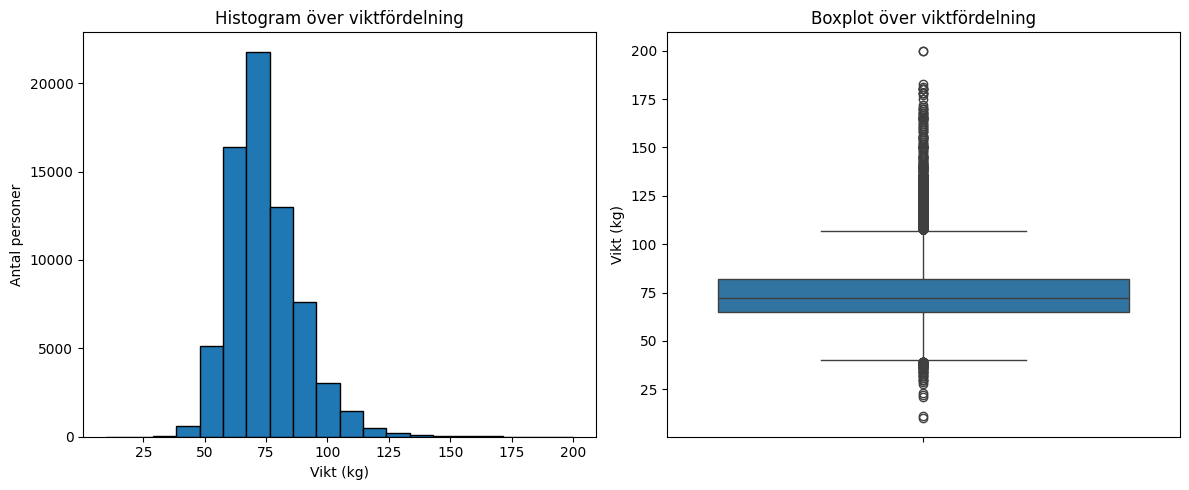

In [6]:
# Hur ser viktfördelningen ut?

plt.figure(figsize=(12, 5))  

plt.subplot(1, 2, 1)  
plt.hist(df["weight"], bins=20, edgecolor='black')
plt.xlabel("Vikt (kg)")
plt.ylabel("Antal personer")
plt.title("Histogram över viktfördelning")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["weight"])
plt.ylabel("Vikt (kg)")
plt.title("Boxplot över viktfördelning")

plt.tight_layout()  
plt.show()


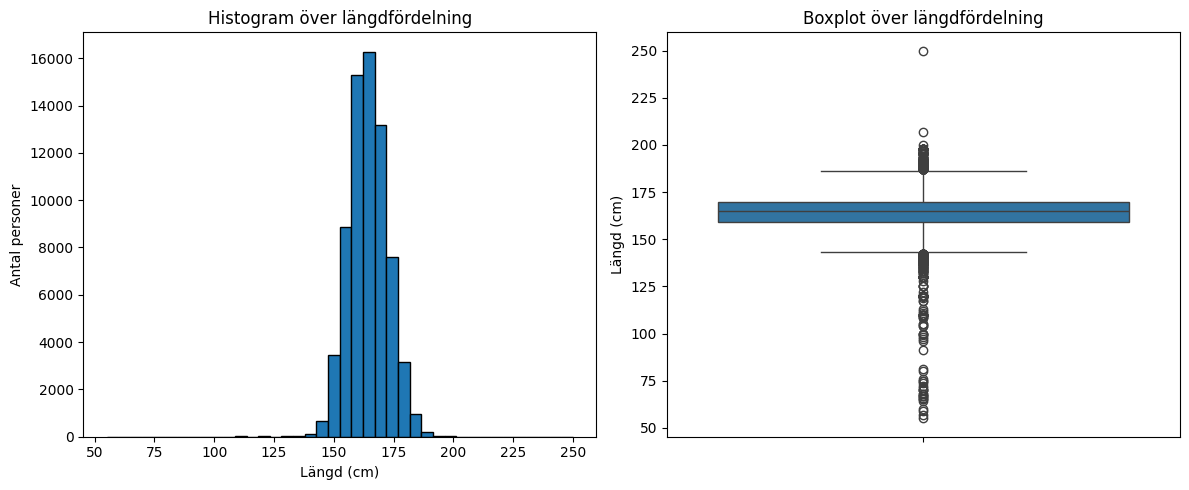

In [7]:
# Hur ser längdfördelningen ut?

plt.figure(figsize=(12, 5))  

plt.subplot(1, 2, 1)  
plt.hist(df["height"], bins=40, edgecolor='black')
plt.xlabel("Längd (cm)")
plt.ylabel("Antal personer")
plt.title("Histogram över längdfördelning")

plt.subplot(1, 2, 2)
sns.boxplot(y=df["height"])
plt.ylabel("Längd (cm)")
plt.title("Boxplot över längdfördelning")

plt.tight_layout()  
plt.show()


Antal män med hjärt- och kärlsjukdomar: 12363
Antal kvinnor med hjärt- och kärlsjukdomar: 22616


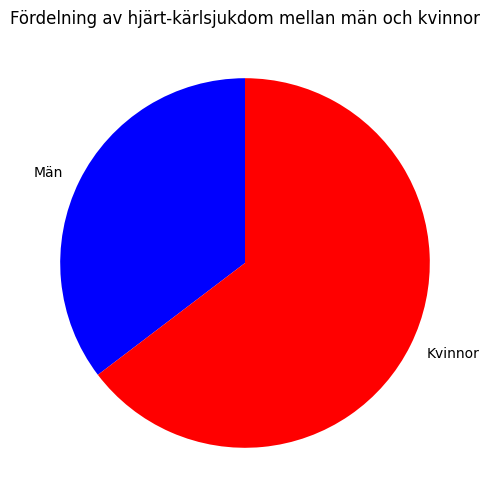

In [8]:
# Hur ser fördelningen av hjärt- och kärlsjukdomar ut mellan män och kvinnor?

df_men = df[(df["cardio"] == 1) & (df["gender"] == 2)]
df_women = df[(df["cardio"] == 1) & (df["gender"] == 1)]

print(f"Antal män med hjärt- och kärlsjukdomar: {len(df_men)}")
print(f"Antal kvinnor med hjärt- och kärlsjukdomar: {len(df_women)}")

labels = ["Män", "Kvinnor"]
gender_split = [len(df_men), len(df_women)]
colors = ["blue", "red"] 

plt.figure(figsize=(6, 6))
plt.pie(gender_split, labels=labels, startangle=90, colors=colors)  
plt.title("Fördelning av hjärt-kärlsjukdom mellan män och kvinnor")

plt.show()


## Feature Engineering: BMI

För att beräkna BMI för varje individ i datasetet genomfördes feature engineering.

### **Beräkning av BMI**

Formeln för BMI definieras som:

$BMI = \frac{\text{vikt (kg)}}{\text{längd (m)}^2}$

Eftersom längduppgifterna i datasetet var angivna i centimeter konverterades dessa till meter för att matcha BMI-formelns krav. Därefter beräknades BMI-värdena för varje individ.

### **Kategorisering av BMI**

För att analysera fördelningen av BMI delades värdena in i följande kategorier:

    Normalvikt: 18.5 - 24.9
    Övervikt: 25 - 29.9
    Fetma klass 1: 30 - 34.9
    Fetma klass 2: 35 - 39.9
    Fetma klass 3: > 40

**Källor**

BMI-formel: [Wikipedia](https://en.wikipedia.org/wiki/Body_mass_index)

Val av BMI-gränser:

[ENN Online](https://www.ennonline.net/fex/15/en/limits-human-starvation)

[Wikipedia - List of heaviest people](https://en.wikipedia.org/wiki/List_of_heaviest_people)

In [9]:
# Hur ser BMI-fördelningen ut?

# Längden omvandlades från cm till meter för att göra det enklare att räkna ut BMI.
df["height_meters"] = df["height"] / 100

# Formeln för BMI utfördes sedan på varje rad i DataFrame.
df["BMI"] = df["weight"] / (df["height_meters"] ** 2)

# Eftersom kolumnen "height_meters" inte längre behövs så togs den bort.
df.drop(columns=["height_meters"], inplace=True)

# BMI-värden över eller under vissa värden togs bort:
    # Värden under 10 togs bort då de bör vara felaktiga på grund av hur låga de är. BMI under 10 kan förekomma i vissa sällsynta fall av svält i kvinnor, men bör inte förekomma i detta dataset.
    # Värden över 60 togs bort då BMI över 60 är extremt ovanligt och kan vara felaktiga i datasetet. De kan förekomma men då är det i samband med extrem fetma.
df = df[(df["BMI"] >= 10) & (df["BMI"] <= 60)]


# "float(inf)" användes för att hantera BMI-värden över 40 (det högsta värdet i kategorin "Obese Class III").
BMI_ranges = [18.5, 24.9, 29.9, 34.9, 39.9, float('inf')]
labels = ["Normal weight", "Overweight", "Obese Class I", "Obese Class II", "Obese Class III"]

# pd.cut användes för att "klippa in" en kolumn i df och dela upp den i kategorier enligt de BMI-kategorier som nämndes ovan.
df["BMI_category"] = pd.cut(df["BMI"], bins=BMI_ranges, labels=labels)


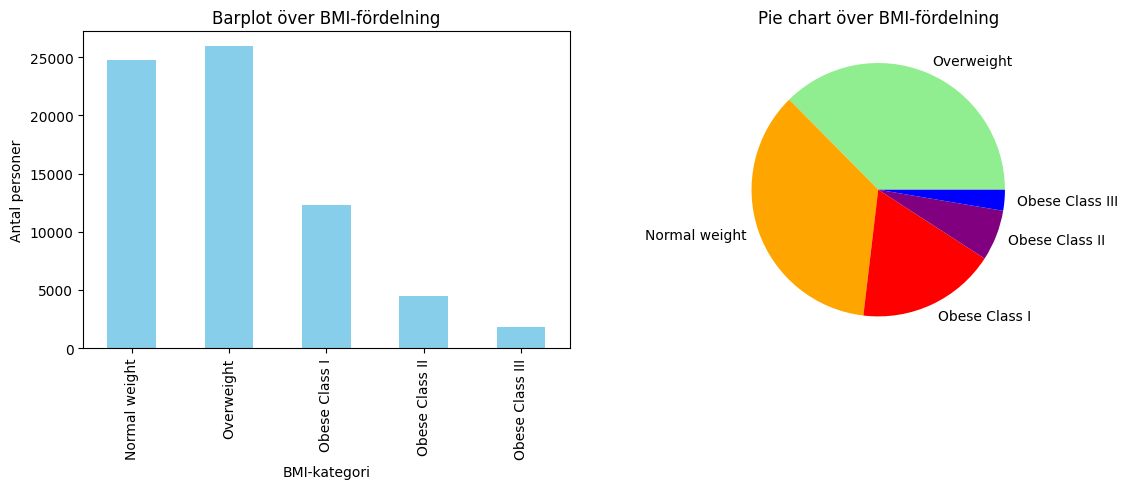

In [10]:
plt.figure(figsize=(12, 5)) 

plt.subplot(1, 2, 1)  
df["BMI_category"].value_counts().sort_index().plot(kind="bar", color="skyblue")
plt.xlabel("BMI-kategori")
plt.ylabel("Antal personer")
plt.title("Barplot över BMI-fördelning")

plt.subplot(1, 2, 2)
df["BMI_category"].value_counts().plot(kind="pie", colors=["lightgreen", "orange", "red", "purple", "blue", "pink"])
plt.ylabel("") 
plt.title("Pie chart över BMI-fördelning")

plt.tight_layout() 
plt.show()


## Feature Engineering: Blodtryck

För att hantera blodtrycksdata i datasetet genomfördes feature engineering för att filtrera ut orimliga värden och kategorisera blodtrycksnivåer.

### **Filtrering av orimliga värden**
Blodtrycket var uppdelat i **systoliskt blodtryck** (`ap_hi`) och **diastoliskt blodtryck** (`ap_lo`). För att säkerställa att data var realistisk togs värden utanför följande intervall bort:

- **Systoliskt blodtryck (ap_hi):** 60 - 300 mmHg  
- **Diastoliskt blodtryck (ap_lo):** 30 - 200 mmHg  

Dessa gränser valdes baserat på medicinska riktlinjer:

- [Healthline – Högt blodtryck](https://www.healthline.com/health/high-blood-pressure-hypertension#symptoms)
- [National Heart, Lung, and Blood Institute – Lågt blodtryck](https://www.nhlbi.nih.gov/health/low-blood-pressure)

### **Kategorisering av blodtrycksnivåer**
Efter filtrering delades blodtrycket in i kategorier enligt etablerade medicinska riktlinjer:

- **Healthy:** ap_hi < 120 och ap_lo < 80  
- **Elevated:** ap_hi 120-129 och ap_lo < 80  
- **Stage 1 Hypertension:** ap_hi 130-139 eller ap_lo 80-89  
- **Stage 2 Hypertension:** ap_hi 140-180 eller ap_lo 90-120  
- **Hypertensive Crisis:** ap_hi > 180 eller ap_lo > 120  

Kategoriseringen implementerades genom att applicera en funktion på datasetet, där varje individ tilldelades en blodtryckskategori.

### **Verifiering av resultat**
Slutligen granskades ett urval av datasetet för att säkerställa att kategoriseringen av blodtryck hade genomförts korrekt.


In [11]:
# Hur ser blodtrycksfördelningen ut?

df = df[(df["ap_hi"] >= 60) & (df["ap_hi"] <= 300)]
df = df[(df["ap_lo"] >= 30) & (df["ap_lo"] <= 200)]

# Funktionen categorize_blood_pressure skapades för att kategorisera blodtrycksvärdena i olika kategorier.
def categorize_blood_pressure(ap_hi, ap_lo):
    if ap_hi > 180 or ap_lo > 120:
        return "Hypertensive Crisis"
    elif ap_hi >= 140 or ap_lo >= 90:
        return "Stage 2 Hypertension"
    elif ap_hi >= 130 or ap_lo >= 80:
        return "Stage 1 Hypertension"
    elif ap_hi >= 120 and ap_lo < 80:
        return "Elevated"
    else:
        return "Healthy"

# df.apply() användes för att applicera funktionen "categorize_blood_pressure" på varje rad i DataFrame.
df["BP_category"] = df.apply(lambda row: categorize_blood_pressure(row["ap_hi"], row["ap_lo"]), axis=1)

# Ett sample på 10 rader togs för att visa hur kolumnerna "ap_hi", "ap_lo" och "BP_category" ser ut.
df.sample(10)[["ap_hi", "ap_lo", "BP_category"]]


,ap_hi,ap_lo,BP_category
43562,120,80,Stage 1 Hypertension
65205,120,90,Stage 2 Hypertension
44265,120,80,Stage 1 Hypertension
13636,130,100,Stage 2 Hypertension
43454,120,80,Stage 1 Hypertension
39503,120,80,Stage 1 Hypertension
55102,160,100,Stage 2 Hypertension
68597,120,80,Stage 1 Hypertension
17119,120,80,Stage 1 Hypertension
54960,130,70,Stage 1 Hypertension


## Analys av hjärt- och kärlsjukdomar i datasetet

För att analysera hur olika faktorer påverkar risken för hjärt- och kärlsjukdomar genomfördes en statistisk undersökning där förekomsten av hjärtsjukdom beräknades för olika grupper inom datasetet. Genom att gruppera individer baserat på specifika hälsovariabler kunde mönster identifieras och visualiseras.

#### Beräkning av andelen sjuka per kategori

Följande kategorier undersöktes:

    Blodtryckskategorier (BP_category)
    BMI-kategorier (BMI_category)
    Kolesterolnivåer (cholesterol)
    Rökning (smoke)
    Ålder (age_years)

Genom att använda funktionen .groupby() i pandas beräknades medelvärdet av cardio-variabeln för varje kategori. Eftersom cardio är en binär variabel (0 = frisk, 1 = sjuk) motsvarar medelvärdet andelen individer med hjärt- och kärlsjukdom i respektive grupp.

För att säkerställa korrekt etikettering av rökning (smoke), där variabeln är numerisk (0 = Nej, 1 = Ja), konverterades dess index till strängar:

df_cardio_smoke.index = df_cardio_smoke.index.astype(str)




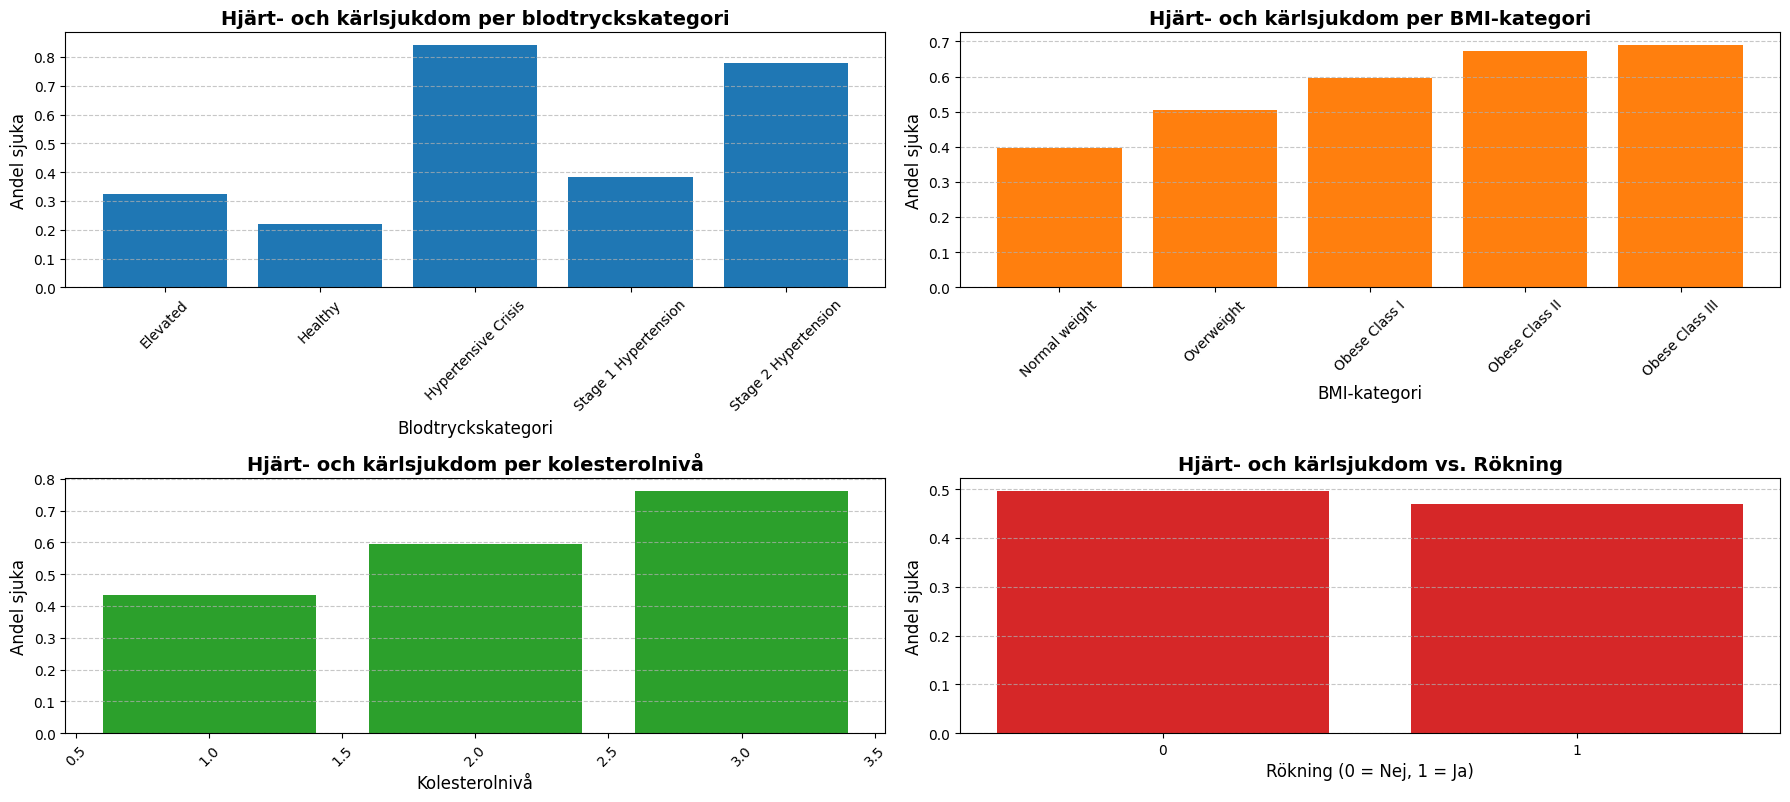

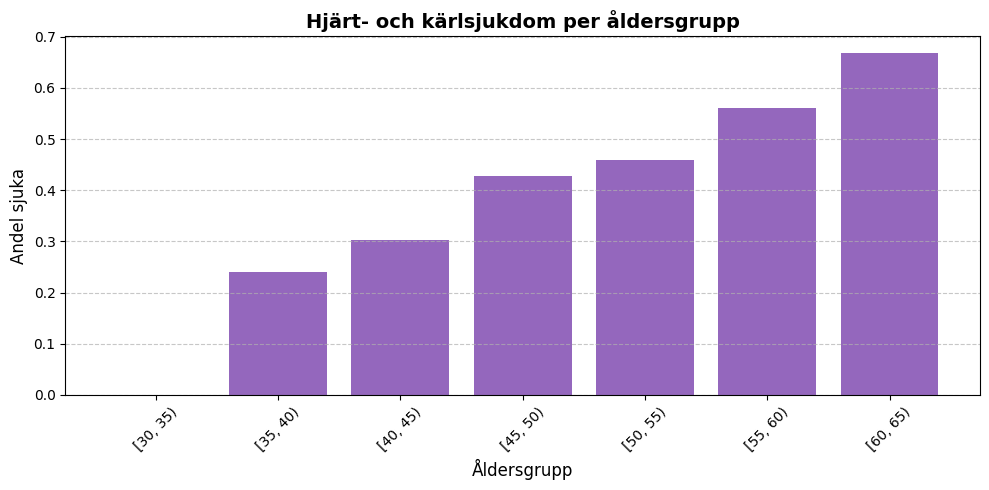

In [12]:
df_cardio_bp = df.groupby("BP_category")["cardio"].mean()
df_cardio_BMI = df.groupby("BMI_category", observed=False)["cardio"].mean()
df_cardio_chol = df.groupby("cholesterol")["cardio"].mean()
df_cardio_smoke = df.groupby("smoke")["cardio"].mean()
df_cardio_age = df.groupby("age_years")["cardio"].mean()

df_cardio_smoke.index = df_cardio_smoke.index.astype(str)

plt.figure(figsize=(18, 12))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

# Subplot 1: Blodtryckskategorier
plt.subplot(3, 2, 1)  
plt.bar(df_cardio_bp.index, df_cardio_bp, color=colors[0])
plt.xlabel("Blodtryckskategori", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per blodtryckskategori", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Subplot 2: BMI-kategorier
plt.subplot(3, 2, 2)  
plt.bar(df_cardio_BMI.index, df_cardio_BMI, color=colors[1])
plt.xlabel("BMI-kategori", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per BMI-kategori", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Subplot 3: Kolesterolnivåer
plt.subplot(3, 2, 3)  
plt.bar(df_cardio_chol.index, df_cardio_chol, color=colors[2])
plt.xlabel("Kolesterolnivå", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per kolesterolnivå", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Subplot 4: Rökning
plt.subplot(3, 2, 4)  
plt.bar(df_cardio_smoke.index, df_cardio_smoke, color=colors[3])
plt.xlabel("Rökning (0 = Nej, 1 = Ja)", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom vs. Rökning", fontsize=14, fontweight="bold")
plt.xticks(rotation=0, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.subplots_adjust(hspace=0.5)
plt.tight_layout()



df_cardio_age_group = df.groupby(pd.cut(df["age_years"], bins=range(30, 71, 5), right=False), observed=False)["cardio"].mean()



plt.figure(figsize=(10, 5))
plt.bar(df_cardio_age_group.index.astype(str), df_cardio_age_group, color="#9467bd")
plt.xlabel("Åldersgrupp", fontsize=12)
plt.ylabel("Andel sjuka", fontsize=12)
plt.title("Hjärt- och kärlsjukdom per åldersgrupp", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, fontsize=10) 
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()


In [13]:
# Nedan skapades en korrelationsmatris för att se hur de olika features korrelerar med varandra.

correlation_matrix = df.corr(numeric_only=True)
print(correlation_matrix)


                   id       age    gender    height    weight     ap_hi  \
id           1.000000  0.003501  0.003107 -0.003438 -0.001775  0.001303   
age          0.003501  1.000000 -0.023131 -0.084572  0.055224  0.208708   
gender       0.003107 -0.023131  1.000000  0.514169  0.157904  0.061439   
height      -0.003438 -0.084572  0.514169  1.000000  0.310484  0.019322   
weight      -0.001775  0.055224  0.157904  0.310484  1.000000  0.269377   
ap_hi        0.001303  0.208708  0.061439  0.019322  0.269377  1.000000   
ap_lo       -0.000608  0.152626  0.066544  0.036796  0.249302  0.696851   
cholesterol  0.005892  0.155515 -0.036624 -0.053863  0.142351  0.193952   
gluc         0.002272  0.099149 -0.021055 -0.020564  0.107722  0.092575   
smoke       -0.003332 -0.047841  0.338760  0.194170  0.067374  0.027159   
alco         0.000669 -0.029014  0.170952  0.097807  0.068528  0.032517   
active       0.003753 -0.010512  0.005929 -0.008454 -0.018393 -0.001336   
cardio       0.003779  0.

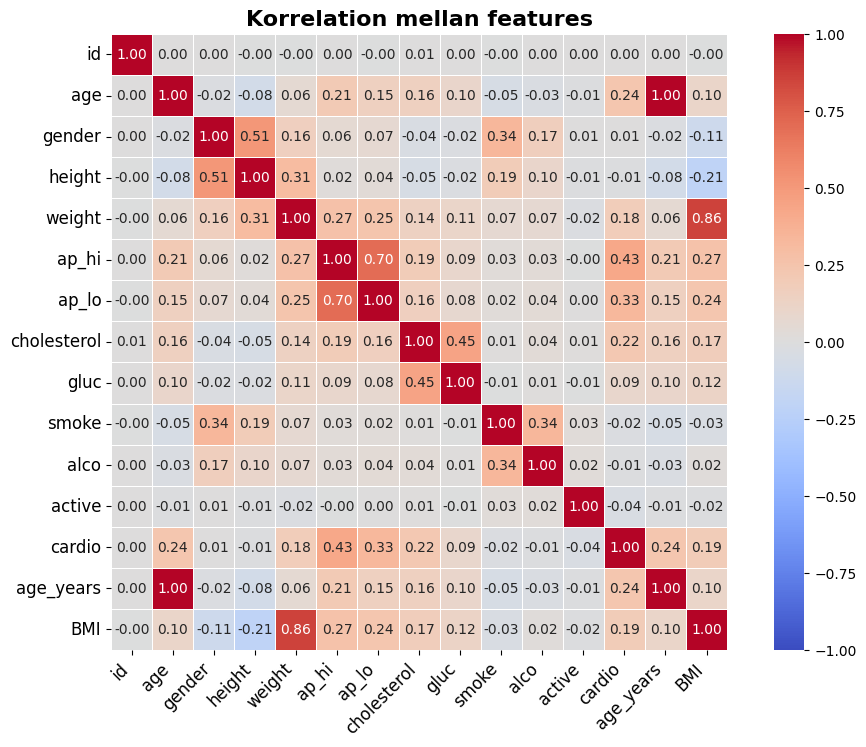

In [14]:
# En heatmap skapades för att visualisera korrelationen mellan features.

plt.figure(figsize=(12, 8))


sns.heatmap(
    correlation_matrix, 
    annot=True,         
    cmap="coolwarm",   
    fmt=".2f",         
    linewidths=0.5,     
    square=True,       
    vmin=-1, vmax=1
)

plt.xticks(rotation=45, ha="right", fontsize=12)  
plt.yticks(fontsize=12) 
plt.title("Korrelation mellan features", fontsize=16, fontweight="bold")

plt.show()


## Korrelation mellan variabler och hjärt- och kärlsjukdomar

Analysen av korrelationer i heatmappen identifierade flera samband mellan olika faktorer och förekomsten av hjärt- och kärlsjukdomar.

#### Blodtryck (ap_hi och ap_lo) och hjärt- och kärlsjukdomar

En tydlig positiv korrelation observerades mellan systoliskt blodtryck (ap_hi), diastoliskt blodtryck (ap_lo) och förekomsten av hjärt- och kärlsjukdomar (cardio). Högt blodtryck är en känd riskfaktor för hjärt-kärlsjukdomar, vilket bekräftades av resultatet.

#### Ålder, kolesterol och BMI som riskfaktorer

En positiv korrelation identifierades mellan ålder och hjärtsjukdomar, vilket kan förklaras av att äldre individer ofta har en ökad förekomst av riskfaktorer såsom högt blodtryck, kolesterol och metabola sjukdomar. Dessutom visade kolesterolnivåer och BMI en positiv koppling till hjärtsjukdom, vilket stöder befintliga medicinska insikter om att höga kolesterolnivåer och fetma är betydande riskfaktorer.

#### Stark korrelation mellan systoliskt och diastoliskt blodtryck

En hög korrelation (0.7) mellan ap_hi och ap_lo noterades, vilket är förväntat eftersom dessa två blodtrycksvärden tenderar att förändras samtidigt.

#### Samband mellan glukos och kolesterol

En måttlig korrelation identifierades mellan glukosnivåer (gluc) och kolesterol (cholesterol). En möjlig förklaring är att båda faktorer kan påverkas av ohälsosamma kostvanor och metabola syndrom, vilket kan öka risken för både diabetes och hjärtsjukdomar.

#### Låg korrelation mellan fysisk aktivitet och hjärtsjukdomar

Förvånansvärt nog observerades en låg korrelation mellan fysisk aktivitet (active) och hjärt- och kärlsjukdomar. En förväntad skyddande effekt av fysisk aktivitet kunde inte bekräftas i denna analys, vilket kan indikera att andra faktorer, såsom kost och genetik, spelar en större roll i detta dataset.



In [15]:
# Två separata DataFrames skapades för att användas i modelleringen; df1 och df2. 
# df1 skulle ej innehålla kolumnerna "ap_hi", "ap_lo", "height", "weight" och "BMI" och;
# df2 skulle ej innehålla kolumnerna "BMI_category", "BP_category", "height" och "weight".

df1 = df.drop(columns=["ap_hi", "ap_lo", "height", "weight", "BMI"])
df2 = df.drop(columns=["BMI_category", "BP_category", "height", "weight"])

df1 = pd.get_dummies(df1, columns=["BMI_category", "BP_category", "gender"], drop_first=True)
df2 = pd.get_dummies(df2, columns=["gender"], drop_first=True)


In [16]:
from sklearn.model_selection import train_test_split

# Data delades upp i tränings-, validerings- och testdata för båda DataFrames.

X_train1, X_test1, y_train1, y_test1 = train_test_split(df1.drop(columns=["cardio"]), df1["cardio"], test_size=0.2, random_state=42)
X_train2, X_test2, y_train2, y_test2 = train_test_split(df2.drop(columns=["cardio"]), df2["cardio"], test_size=0.2, random_state=42)


X_val1, X_test1, y_val1, y_test1 = train_test_split(X_test1, y_test1, test_size=0.5, random_state=42)
X_val2, X_test2, y_val2, y_test2 = train_test_split(X_test2, y_test2, test_size=0.5, random_state=42)


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# De båda datasetten standardiserades och normaliserades med hjälp av en pipeline.

std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

pipe = Pipeline([
    ("standardizer", StandardScaler()),
    ("normalizer", MinMaxScaler())
])

X_train_scaled_1 = pipe.fit_transform(X_train1)
X_val_scaled_1 = pipe.transform(X_val1)
X_test_scaled_1 = pipe.transform(X_test1)

X_train_scaled_2 = pipe.fit_transform(X_train2)
X_val_scaled_2 = pipe.transform(X_val2)
X_test_scaled_2 = pipe.transform(X_test2)



In [ ]:
# "Param grids" skapades för att användas i GridSearchCV för att hitta de bästa hyperparametrarna för varje modell.

param_grid_logreg = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],  
    "solver": ["liblinear", "lbfgs", "saga"],
    "penalty": ["l2"] 
}


param_grid_lin_svc = {
    "C": [0.1, 1, 10],
    "dual": [False], # Inställdes till False för att bättre hantera stora dataset
    "max_iter": [1000] 
}


param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11],  
    "weights": ["uniform", "distance"], 
    "metric": ["euclidean", "manhattan"]
}

param_grid_rf = {
    "n_estimators": [50, 100, 200], 
    "max_depth": [None, 10, 20, 30], 
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4] 
}


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

logreg_model = LogisticRegression(max_iter=1000, warm_start=True)
linear_svc_model = LinearSVC()
knn_model = KNeighborsClassifier()
rf_model = RandomForestClassifier()




In [ ]:
best_params_dict = {}


# En funktion skapades för att köra GridSearchCV för varje modell och hitta de bästa hyperparametrarna.
def run_grid_search(model, param_grid, X_train, y_train, model_name):
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring="recall", n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    
    best_params_dict[model_name] = grid_search.best_params_  
    
    print(f"Bästa parametrar för {model_name}: {grid_search.best_params_}")
    print(f"Bästa validerings-accuracy: {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_



In [21]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=10000), param_grid_logreg),
    "LinearSVC": (LinearSVC(), param_grid_lin_svc),
    "KNN": (KNeighborsClassifier(), param_grid_knn),
    "Random Forest": (RandomForestClassifier(), param_grid_rf)
}

best_models = {}

for name, (model, param_grid) in models.items():
    print(f"\n🔍 Tränar {name} på dataset 1...")
    best_models[f"{name}_df1"] = run_grid_search(model, param_grid, X_train_scaled_1, y_train1, name)
    
    print(f"\n🔍 Tränar {name} på dataset 2...")
    best_models[f"{name}_df2"] = run_grid_search(model, param_grid, X_train_scaled_2, y_train2, name)



🔍 Tränar Logistic Regression på dataset 1...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Bästa parametrar för Logistic Regression: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Bästa validerings-accuracy: 0.6501

🔍 Tränar Logistic Regression på dataset 2...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Bästa parametrar för Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Bästa validerings-accuracy: 0.6693

🔍 Tränar LinearSVC på dataset 1...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Bästa parametrar för LinearSVC: {'C': 1, 'dual': False, 'max_iter': 1000}
Bästa validerings-accuracy: 0.6338

🔍 Tränar LinearSVC på dataset 2...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Bästa parametrar för LinearSVC: {'C': 1, 'dual': False, 'max_iter': 1000}
Bästa validerings-accuracy: 0.6587

🔍 Tränar KNN på dataset 1...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Bästa parametrar för KNN: {'metric': 

/home/alex/iths/Machine-learning-AI24/.venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Bästa parametrar för Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Bästa validerings-accuracy: 0.7010

🔍 Tränar Random Forest på dataset 2...
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Bästa parametrar för Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Bästa validerings-accuracy: 0.6964


In [22]:
val_predictions = {}

# Prediktioner gjordes med de bästa modellerna för varje dataset.
for name, model in best_models.items():
    print(f"Gör prediction med {name}...")
    val_predictions[name] = model.predict(X_val_scaled_1 if "df1" in name else X_val_scaled_2)

for name, preds in val_predictions.items():
    print(f"{name}: {preds[:10]}")


Gör prediction med Logistic Regression_df1...
Gör prediction med Logistic Regression_df2...
Gör prediction med LinearSVC_df1...
Gör prediction med LinearSVC_df2...
Gör prediction med KNN_df1...
Gör prediction med KNN_df2...
Gör prediction med Random Forest_df1...
Gör prediction med Random Forest_df2...
Logistic Regression_df1: [0 1 1 0 1 0 1 1 0 1]
Logistic Regression_df2: [0 1 1 0 1 1 1 1 0 1]
LinearSVC_df1: [0 1 1 0 1 0 1 1 0 1]
LinearSVC_df2: [0 1 1 0 1 1 1 1 0 1]
KNN_df1: [0 1 1 0 1 0 1 1 0 1]
KNN_df2: [0 1 1 0 1 1 1 1 0 1]
Random Forest_df1: [0 1 1 0 1 0 1 1 0 1]
Random Forest_df2: [0 1 1 0 1 1 1 1 0 1]


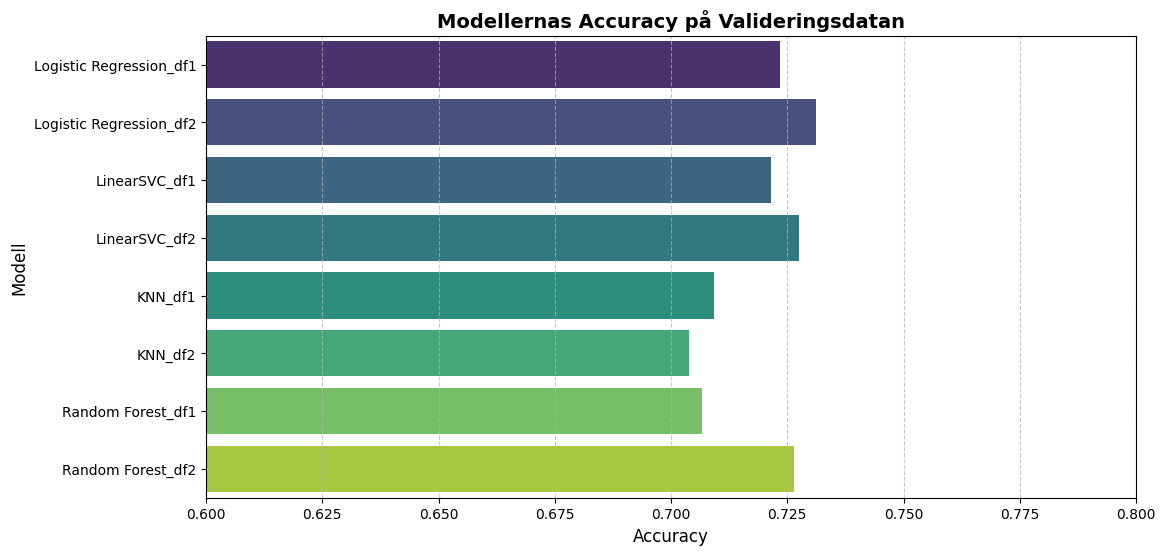

In [23]:
from sklearn.metrics import accuracy_score

# Accuracy_score användes för att utvärdera modellerna på valideringsdatan.
# En DataFrame skapades sedan för att visa accuracy för varje modell.

evaluation_scores = {}

for name, preds in val_predictions.items():
    y_true = y_val1 if "df1" in name else y_val2 
    acc = accuracy_score(y_true, preds)
    evaluation_scores[name] = acc

results_df = pd.DataFrame(evaluation_scores.items(), columns=["Model", "Accuracy"])

plt.figure(figsize=(12, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df, hue="Model", palette="viridis", legend=False)

plt.title("Modellernas Accuracy på Valideringsdatan", fontsize=14, fontweight="bold")
plt.xlabel("Accuracy", fontsize=12)
plt.ylabel("Modell", fontsize=12)
plt.xlim(0.6, 0.8) 
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.show()

In [24]:
# De bästa parametrarna för varje modell skrevs sedan ut.

for model_name, model in best_models.items():

    best_params = model.get_params()

    base_model_name = model_name.split('_df')[0]  
    
    param_grid = models[base_model_name][1]  
    
    relevant_params = {key: value for key, value in best_params.items() if key in param_grid}
    
    print(f"Bästa parametrar för {model_name}: {relevant_params}")



Bästa parametrar för Logistic Regression_df1: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Bästa parametrar för Logistic Regression_df2: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Bästa parametrar för LinearSVC_df1: {'C': 1, 'dual': False, 'max_iter': 1000}
Bästa parametrar för LinearSVC_df2: {'C': 1, 'dual': False, 'max_iter': 1000}
Bästa parametrar för KNN_df1: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Bästa parametrar för KNN_df2: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Bästa parametrar för Random Forest_df1: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Bästa parametrar för Random Forest_df2: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}


In [25]:
from sklearn.ensemble import VotingClassifier

# VotingClassifier användes för att kombinera de bästa modellerna för varje dataset.

vote_clf_df1 = VotingClassifier(
    estimators=[
        ("logreg", LogisticRegression(**best_models["Logistic Regression_df1"].get_params())),
        ("svc", LinearSVC(**best_models["LinearSVC_df1"].get_params())),
        ("knn", KNeighborsClassifier(**best_models["KNN_df1"].get_params())),
        ("rf", RandomForestClassifier(**best_models["Random Forest_df1"].get_params()))
    ],
    voting="hard"
)


vote_clf_df2 = VotingClassifier(
    estimators=[
        ("logreg", LogisticRegression(**best_models["Logistic Regression_df2"].get_params())),
        ("svc", LinearSVC(**best_models["LinearSVC_df2"].get_params())),
        ("knn", KNeighborsClassifier(**best_models["KNN_df2"].get_params())),
        ("rf", RandomForestClassifier(**best_models["Random Forest_df2"].get_params()))
    ],
    voting="hard"
)


In [26]:
# Modellerna tränades på respektive träningsdata.

print("🔍 Tränar VotingClassifier på dataset 1...")
vote_clf_df1.fit(X_train_scaled_1, y_train1)


print("🔍 Tränar VotingClassifier på dataset 2...")
vote_clf_df2.fit(X_train_scaled_2, y_train2)



🔍 Tränar VotingClassifier på dataset 1...
🔍 Tränar VotingClassifier på dataset 2...


VotingClassifier(estimators=[('logreg',
                              LogisticRegression(C=0.1, max_iter=10000,
                                                 solver='saga')),
                             ('svc', LinearSVC(C=1, dual=False)),
                             ('knn',
                              KNeighborsClassifier(metric='euclidean',
                                                   n_neighbors=9,
                                                   weights='distance')),
                             ('rf',
                              RandomForestClassifier(min_samples_split=10,
                                                     n_estimators=50))])

In [27]:
# Prediktioner gjordes med VotingClassifier för varje dataset.
# Accuracy_score användes sedan för att utvärdera modellerna och det dataset med högst accuracy valdes.

vote_preds_df1 = vote_clf_df1.predict(X_val_scaled_1)
vote_preds_df2 = vote_clf_df2.predict(X_val_scaled_2)

accuracy_df1 = accuracy_score(y_val1, vote_preds_df1)
accuracy_df2 = accuracy_score(y_val2, vote_preds_df2)

print(f"Accuracy för VotingClassifier på df1: {accuracy_df1:.4f}")
print(f"Accuracy för VotingClassifier på df2: {accuracy_df2:.4f}")


chosen_dataset = "df1" if accuracy_df1 > accuracy_df2 else "df2"
print(f"Valt dataset: {chosen_dataset}")


Accuracy för VotingClassifier på df1: 0.7211
Accuracy för VotingClassifier på df2: 0.7296
Valt dataset: df2


In [30]:

# Den bästa modellen valdes också ut.

best_model_name = max(evaluation_scores, key=evaluation_scores.get)
print(f"Bästa enskilda modellen: {best_model_name}")


Bästa enskilda modellen: Logistic Regression_df2



Bästa tröskelvärdet: 0.3
              precision    recall  f1-score   support

           0       0.82      0.37      0.51      3496
           1       0.58      0.91      0.71      3376

    accuracy                           0.64      6872
   macro avg       0.70      0.64      0.61      6872
weighted avg       0.70      0.64      0.61      6872



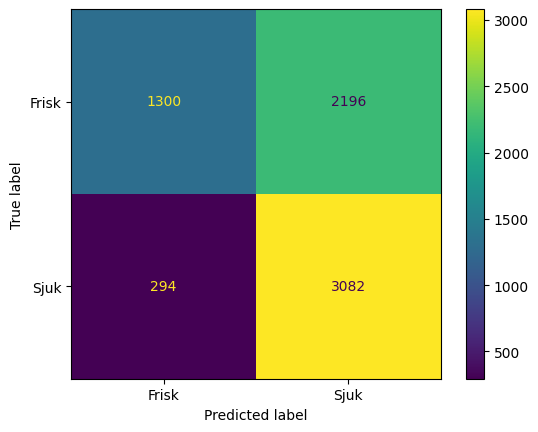

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Den bästa Logistic-Regression-modellen (baserat på tidigare hyperparameteroptimering) valdes.
# Modellen tränades på både tränings- och valideringsdata för att maximera mängden träningsdata.
final_model = LogisticRegression(**best_models["Logistic Regression_df2"].get_params())
final_model.fit(np.vstack([X_train_scaled_2, X_val_scaled_2]), np.hstack([y_train2, y_val2]))

# Sannolikheter för klass 1 ("sjuk") beräknades för testdatan.
y_prob = final_model.predict_proba(X_test_scaled_2)[:, 1]

# Flera tröskelvärden testades för att undersöka vilken gräns som gav bäst resultat.
thresholds = [0.5, 0.4, 0.3]
best_threshold = None
best_cm = None
best_tp = 0  # Antalet korrekt predikterade positiva (True Positives) initialiserades
best_y_pred = None

# För varje tröskelvärde beräknades en justerad klassprediktion samt en confusion matrix
for t in thresholds:
    y_pred_adjusted = (y_prob > t).astype(int)  # Prediktionerna justerades enligt aktuell tröskel
    cm = confusion_matrix(y_test2, y_pred_adjusted)  # En confusion matrix genererades

    tp = cm[1, 1]  # Antalet True Positives hämtades från confusion matrixen

    # Om ett högre antal True Positives hittades, uppdaterades det bästa tröskelvärdet och resultatet
    if tp > best_tp:
        best_tp = tp
        best_threshold = t
        best_cm = cm
        best_y_pred = y_pred_adjusted

# Det bästa tröskelvärdet och motsvarande klassificeringsrapport presenterades
print(f"\nBästa tröskelvärdet: {best_threshold}")
print(classification_report(y_test2, best_y_pred)) 


disp = ConfusionMatrixDisplay(best_cm, display_labels=["Frisk", "Sjuk"])
disp.plot()


## Slutsats

I denna studie användes maskininlärningsmetoder för att analysera ett dataset relaterat till hjärt- och kärlsjukdomar. Syftet var att förutsäga sjukdomstillstånd baserat på olika hälsorelaterade variabler och att optimera en modell genom justering av tröskelvärden.

#### Databearbetning och Feature Engineering:

Orimliga värden inom blodtryck och BMI filtrerades bort.

Blodtryck och BMI kategoriserades enligt etablerade medicinska riktlinjer.

Korrelationer mellan variabler identifierades, där blodtryck och ålder hade starkast koppling till förekomsten av hjärt-kärlsjukdom.

#### Modellutvärdering:

Flera maskininlärningsmodeller testades, varav Random Forest och Logistisk Regression presterade bäst.

Hyperparameteroptimering genomfördes med GridSearchCV för att förbättra prestandan.

En Voting Classifier testades men valdes inte som slutgiltig modell.

#### Optimering av tröskelvärde:

Det bästa tröskelvärdet identifierades till 0.3, vilket ökade återkallelsen (recall) för den positiva klassen (sjuka) till 91%, men på bekostnad av precision.

Confusion-matrisen visade att många friska klassificerades som sjuka (falska positiva), vilket kan leda till onödiga varningar men också innebär att få sjuka missas.

#### Slutlig bedömning

Den valda modellen (Logistic Regression) prioriterade hög recall för att minska risken för falskt negativa diagnoser, vilket är viktigt i medicinska sammanhang där det är bättre att identifiera för många sjuka än att missa verkliga fall.
